In [60]:
%pylab inline
#code units
Mstar = 1
R0 = 1
G = 1
R_MU = 1

#cgs units
kB_CGS = 1.38064852e-16      # erg / K
mH_CGS = 2.4 * 1.67262192369e-24 # g (μ = 2.4)
Mstar_CGS = 1.9891e33            # g
G_CGS = 6.674e-8
AU_CM = 1.49597871e13
R0_CGS = 30.0 * AU_CM
R_MU_CGS = 36149835.0
gamma = 1.4

# ERGS macro for scale-free fondam (G=MSTAR=R0=1): one code energy unit [erg]
ergs_code = 1/((R0/R0_CGS) / ((G/G_CGS) * (Mstar/Mstar_CGS)**2))
Kelvin_code = ((G*Mstar/R0/R_MU)/(G_CGS*Mstar_CGS/R0_CGS/R_MU_CGS))

# k_B in code units ergs per kelvin
kB_code = kB_CGS * ergs_code/ Kelvin_code

# One particle mass in code units if 1 code mass = one stellar mass
mH_code = mH_CGS * (Mstar/ Mstar_CGS)


print(kB_code/ mH_code)


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
0.9514101616899104


/Users/nadine/venvs/nadine/lib/python3.13/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['time', 'gamma', 'amin']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [72]:
def plot_vz(folder, n):
    rmin = loadtxt("../../outputs/" + folder +"/domain_y.dat")[3:-3]
    tmin = loadtxt("../../outputs/" + folder +"/domain_z.dat")[3:-3]

    rmed = 0.5 * (rmin[1:] + rmin[:-1])
    tmed = 0.5 * (tmin[1:] + tmin[:-1])

    R, T = meshgrid(rmed, tmed)

    nz = 128
    ny = 128


    vthetan_th = fromfile("../../outputs/" + folder+ "/gasvz{:d}.dat".format(n)).reshape(nz,ny)
    vthetan_d= fromfile("../../outputs/" + folder +"/dust1vz{:d}.dat".format(n)).reshape(nz,ny)

    cg = R_MU /(gamma -1)
    cd = 0.088* cg


    H0 = 0.06
    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(211)
    # surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
    surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.003,vmax=0.003)

    ax1.set_xlabel('r (AU)')
    ax1.set_ylabel('z/H')
    ax1.set_xlim(0.6*30, 1.6*30)
    fig.colorbar(surf1, ax=ax1, label=r'$v_{\theta, gas}\, [\rm K]$')

    # fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

    ax2 = fig.add_subplot(212)
    surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.003,vmax=0.003)
    ax2.set_xlabel('r (AU)')
    ax2.set_ylabel('z/H')
    ax2.set_xlim(30*0.6, 30*1.6)
    fig.colorbar(surf2, ax=ax2, label=r'$v_{\theta, dust}$')
    show()

-0.016991351806550255


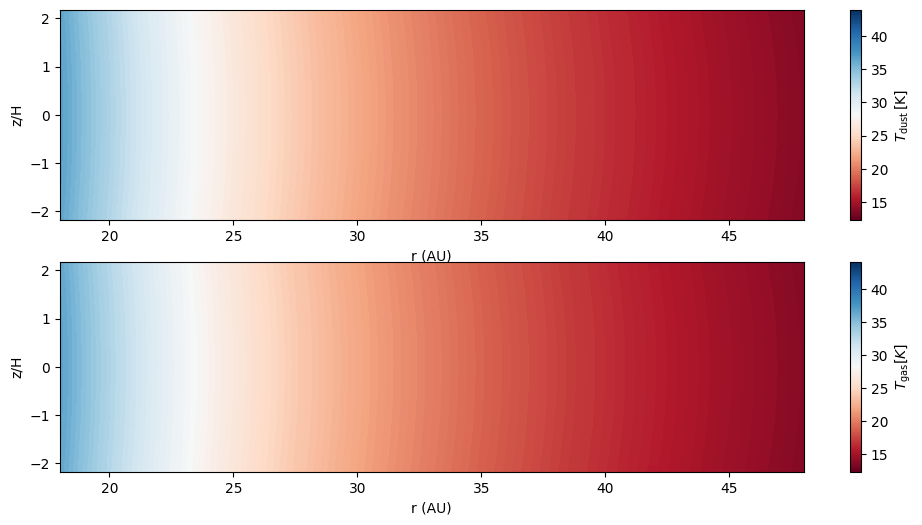

In [44]:
n =6

vthetan_th = fromfile("../../outputs/vsi_128_iso/gasvz{:d}.dat".format(n)).reshape(nz,ny)
rhodn_th = fromfile("../../outputs/vsi_128_iso/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
edn_th = fromfile("../../outputs/vsi_128_iso/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
egn_th = fromfile("../../outputs/vsi_128_iso/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
rhogn_th = fromfile("../../outputs/vsi_128_iso/gasdens{:d}.dat".format(n)).reshape(nz,ny)

# tcol = fromfile("../../outputs/vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = gamma * R_MU /(gamma -1)
cd = 0.088* cg

Tdust = edn_th / rhodn_th / Kelvin_code / cd

Tgas = egn_th / rhogn_th / Kelvin_code / cg

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, Tdust, cmap='RdBu')

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T_{\rm dust}\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, Tgas, cmap='RdBu')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$T_{\rm gas} [K]$')
show()

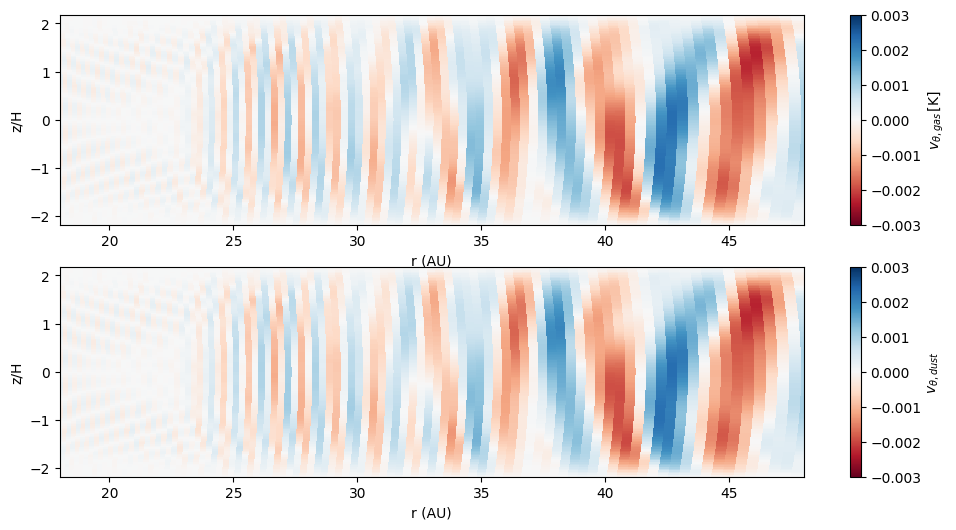

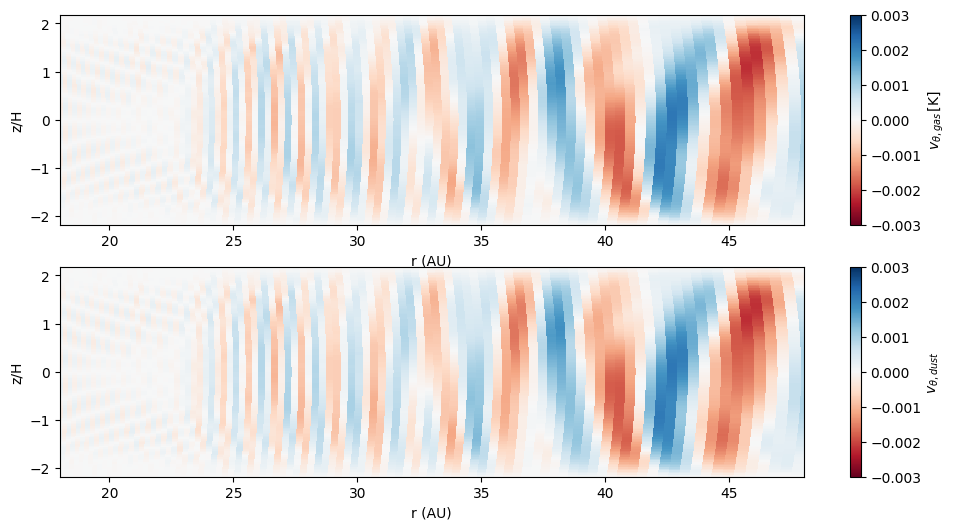

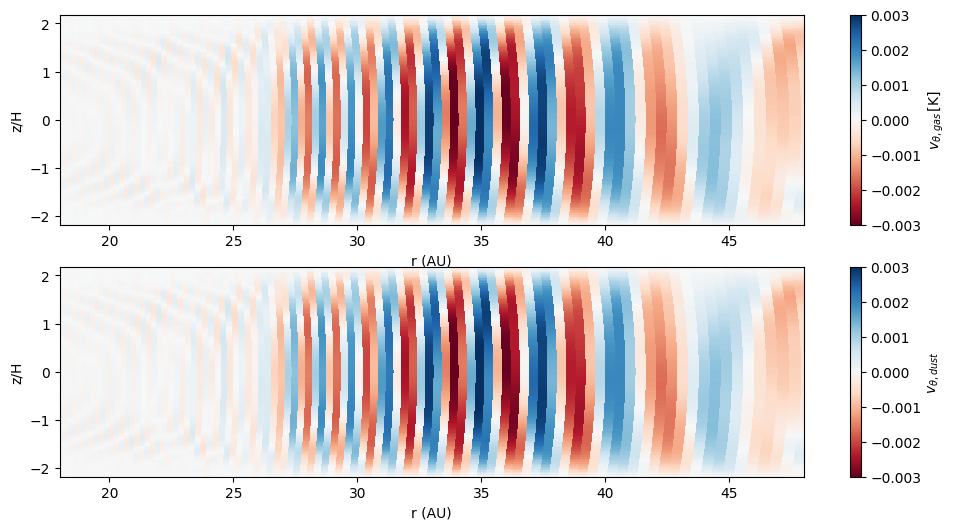

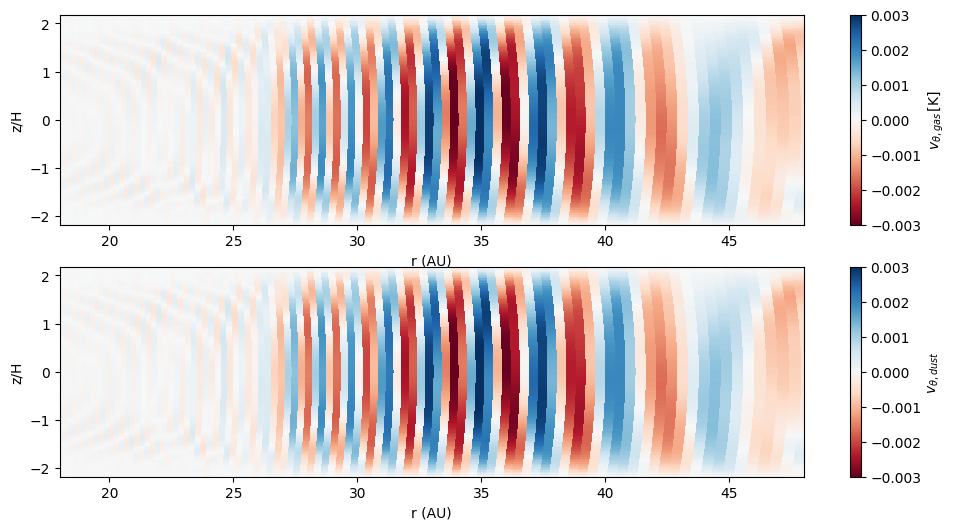

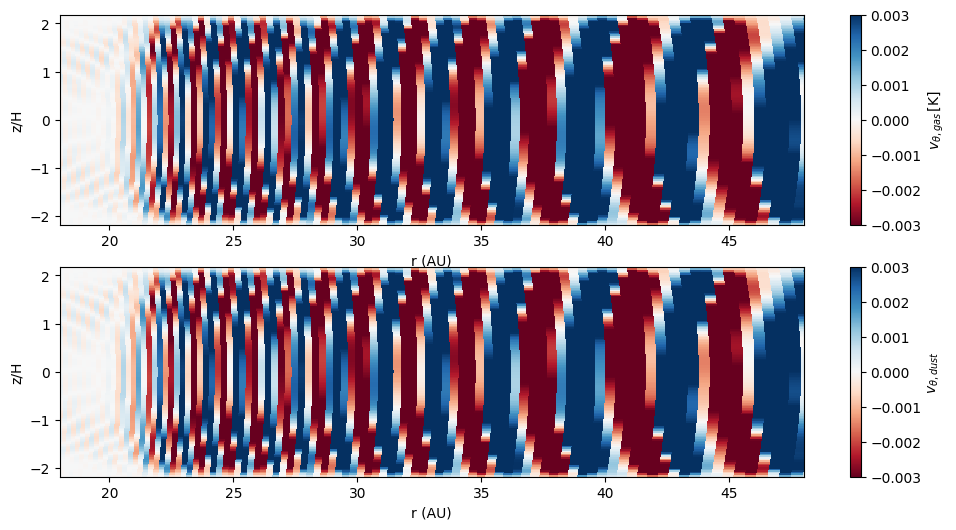

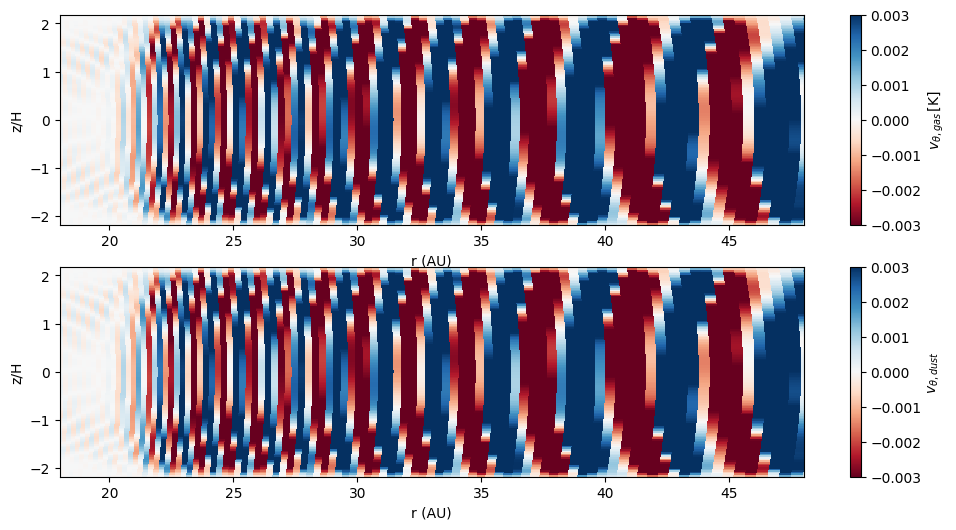

In [74]:
plot_vz("vsi_128_iso", 100)
plot_vz("vsi_128_adi", 100)
plot_vz("vsi_sametemp", 100)
plot_vz("vsi_diffT", 100)
plot_vz("vsi_sameTgrad", 100)
plot_vz("vsi_small_diffT_grad", 100)

-48.887794586934966


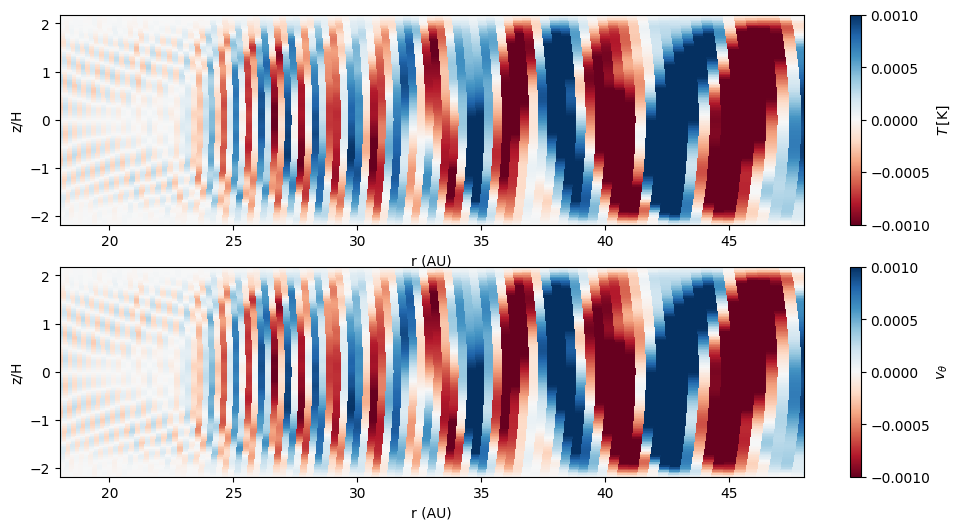

In [47]:
n =100

vthetan_th = fromfile("../../outputs/vsi_128_adi/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_adi/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
tcol= fromfile("../../outputs//vsi_128_adi/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg

# Tdust = edn_th / rhodn_th / Kelvin_code / cd

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(1/np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

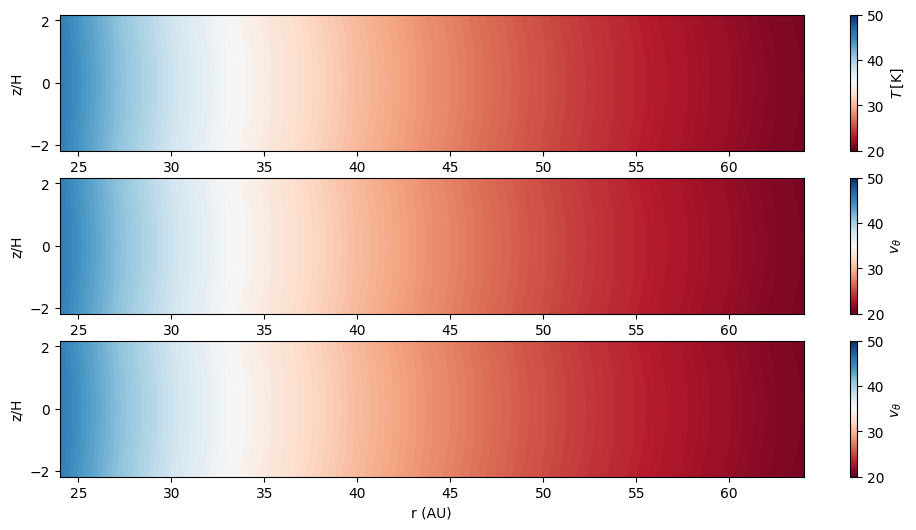

In [42]:
n =0

vthetan_th = fromfile("../../outputs/vsi_sametemp/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_sametemp/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d2= fromfile("../../outputs/vsi_sametemp/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
cg = 1/(gamma-1)
cd = 0.088 * cg
rho = fromfile("../../outputs/vsi_sametemp/gasdens{:d}.dat".format(n)).reshape(nz,ny)
rhod1= fromfile("../../outputs/vsi_sametemp/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
rhod2= fromfile("../../outputs/vsi_sametemp/dust2dens{:d}.dat".format(n)).reshape(nz,ny)

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(311)
surf1 = ax1.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_th/rho/cg / Kelvin_code, cmap='RdBu',vmin = 20, vmax = 50)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*40, 1.6*40)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

ax2 = fig.add_subplot(312)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d/rhod1/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 50)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')

ax2 = fig.add_subplot(313)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d2/rhod2/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 50)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

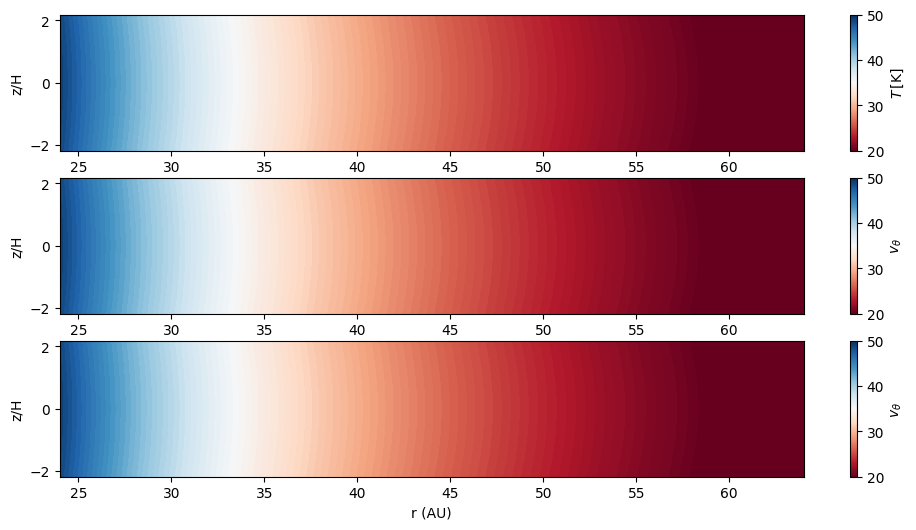

In [20]:
n =0

vthetan_th = fromfile("../../outputs/vsi_2fluids/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_2fluids/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d2= fromfile("../../outputs/vsi_2fluids/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
cg = 1/(gamma-1)
cd = 0.088 * cg
rho = fromfile("../../outputs/vsi_2fluids/gasdens{:d}.dat".format(n)).reshape(nz,ny)
rhod1= fromfile("../../outputs/vsi_2fluids/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
rhod2= fromfile("../../outputs/vsi_2fluids/dust2dens{:d}.dat".format(n)).reshape(nz,ny)

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(311)
surf1 = ax1.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_th/rho/cg / Kelvin_code, cmap='RdBu',vmin = 20, vmax = 50)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*40, 1.6*40)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

ax2 = fig.add_subplot(312)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d/rhod1/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 50)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')

ax2 = fig.add_subplot(313)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d2/rhod2/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 50)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

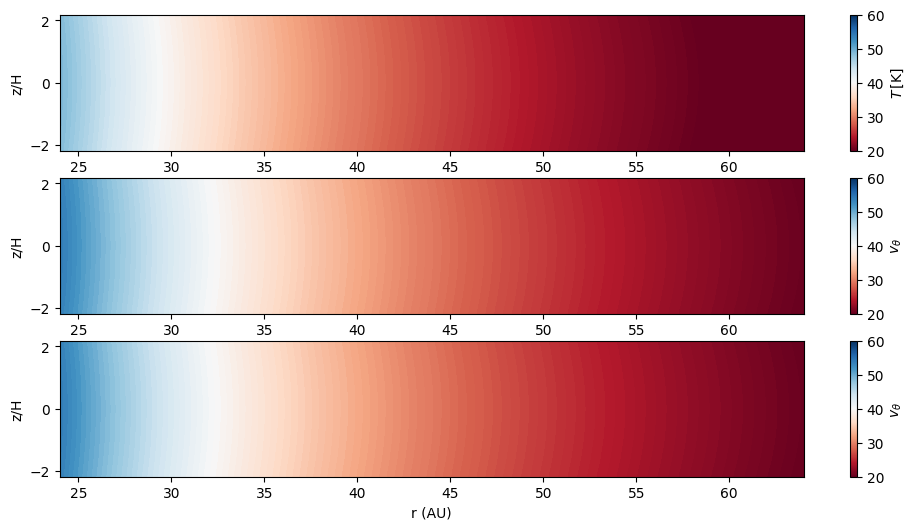

In [12]:
n =0

vthetan_th = fromfile("../../outputs/vsi_128_2fluid/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_128_2fluid/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d2= fromfile("../../outputs/vsi_128_2fluid/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
cg = gamma/(gamma-1)
cd = 0.08 * cg
rho = fromfile("../../outputs/vsi_128_2fluid/gasdens{:d}.dat".format(n)).reshape(nz,ny)
rhod1= fromfile("../../outputs/vsi_128_2fluid/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
rhod2= fromfile("../../outputs/vsi_128_2fluid/dust2dens{:d}.dat".format(n)).reshape(nz,ny)

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(311)
surf1 = ax1.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_th/rho/cg/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 60)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*40, 1.6*40)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

ax2 = fig.add_subplot(312)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d/rhod1/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 60)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')

ax2 = fig.add_subplot(313)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d2/rhod2/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 60)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

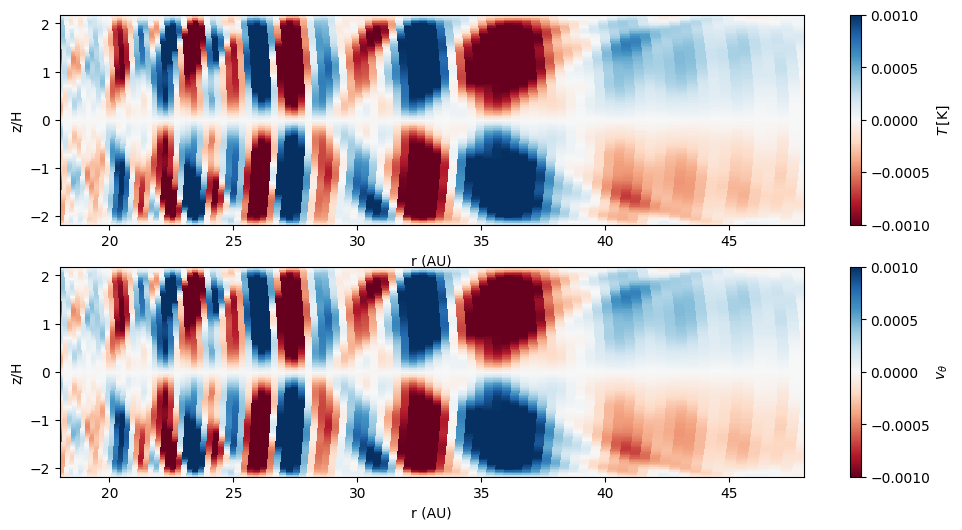

In [43]:
n =19

vthetan_th = fromfile("../../outputs/vsi_128_2fluid/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_2fluid/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

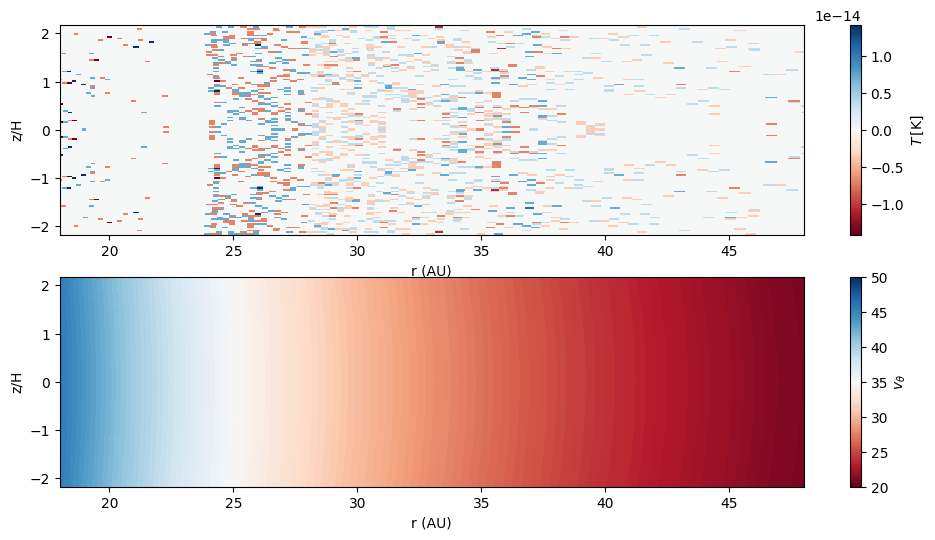

In [83]:
n =0

ed1 = fromfile("../../outputs/vsi_diffT/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
ed2= fromfile("../../outputs/vsi_diffT/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
d1 = fromfile("../../outputs/vsi_diffT/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
d2= fromfile("../../outputs/vsi_diffT/dust2dens{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)




cg = R_MU /(gamma -1)
cd = 0.088* cg
T1 = ed1/d1/cd * temp_units
T2 = ed2/d2/cd * temp_units

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, T1-T2, cmap='RdBu')#, vmin=20,vmax=50)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, T2, cmap='RdBu', vmin=20,vmax=50)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

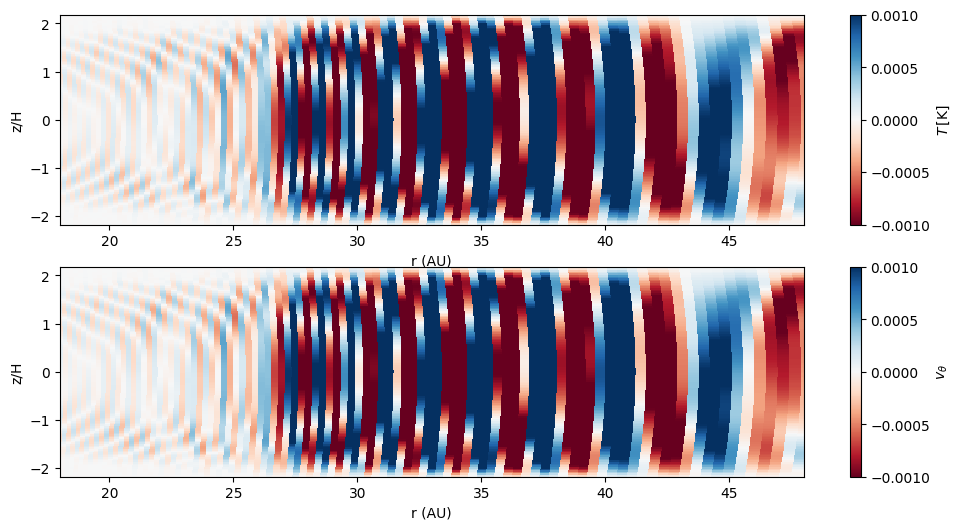

In [48]:
n =100

vthetan_th = fromfile("../../outputs/vsi_sametemp/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_sametemp/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

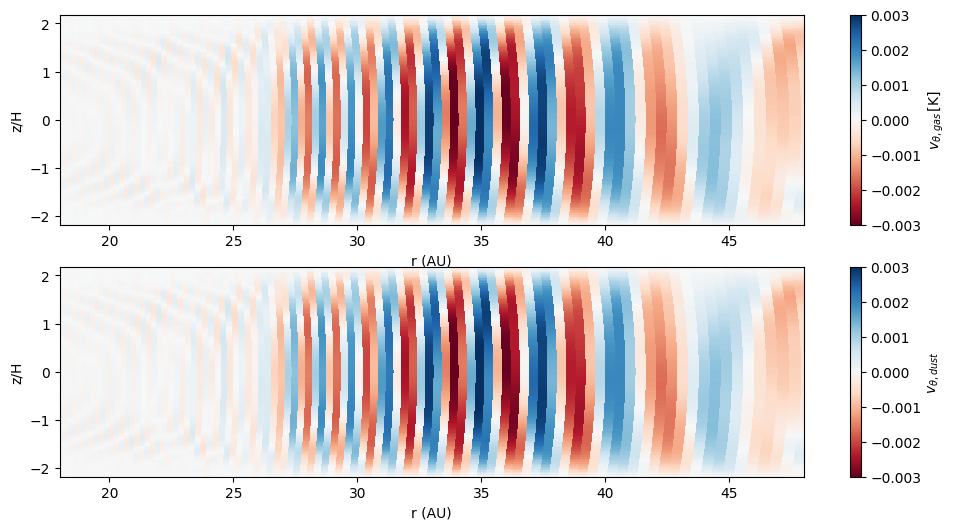

In [63]:
n =100

vthetan_th = fromfile("../../outputs/vsi_diffT/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_diffT/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.003,vmax=0.003)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$v_{\theta, gas}\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.003,vmax=0.003)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_{\theta, dust}$')
show()

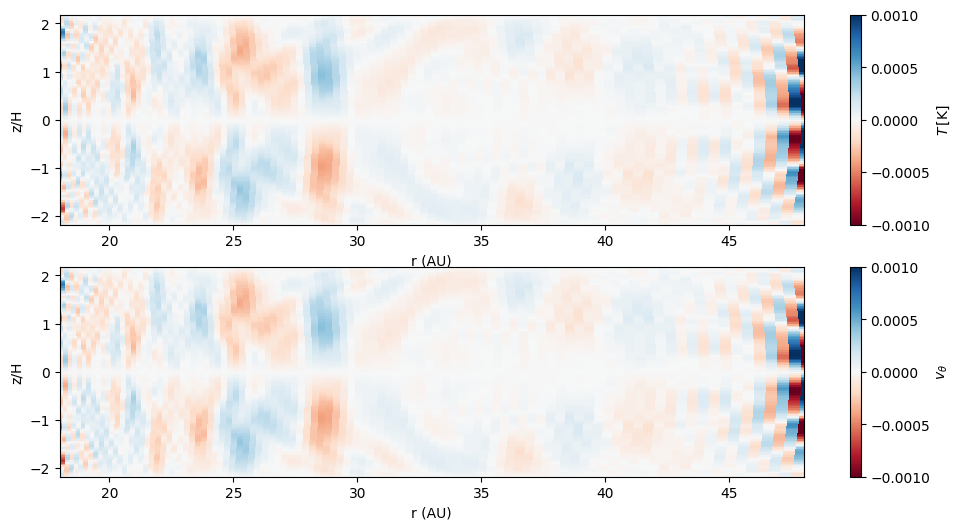

In [59]:
n =78

vthetan_th = fromfile("../../outputs/vsi_sametemp/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_sametemp/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

In [57]:
n = 50

tcol = fromfile("../../outputs/vsi_lin/Tcol{:d}.dat".format(n)).reshape(nz,ny)
H0 = 0.06

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm())
ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
# surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.0001,vmax=0.0001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/vsi_lin/Tcol50.dat'

100
Loaded data for Nsubth=6
100
Loaded data for Nsubth=1


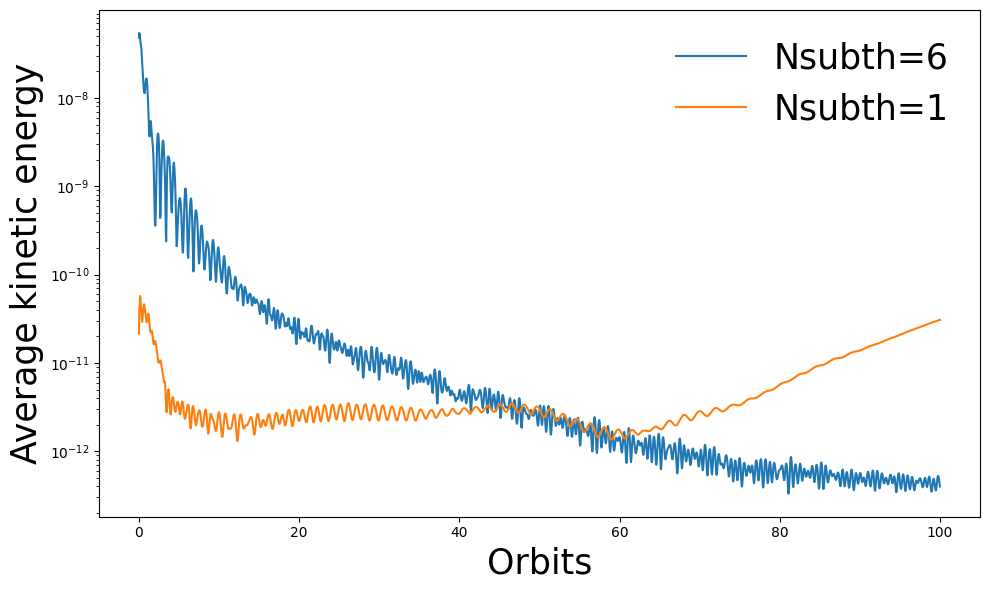

In [55]:
nofb = "../../outputs/vsi_sametemp"
nofb_1 = "../../outputs/vsi_diffT"

import numpy as np
import matplotlib.pyplot as plt
import os

nintern = 20
nout = 100  # base number, can customize per key if needed
ny = 128   # adjust this if your vertical grid size differs

paths = {
    "Nsubth=6": nofb,
    "Nsubth=1": nofb_1,
}

nout_dict = {
    "Nsubth=6": 100,
    "Nsubth=1": 100,
}


# storage for data
monitor_data = {}

# Read and process data for each simulation
for key, path in paths.items():
    try:
        ny = 128
        nx = 128
        nout_val = nout_dict.get(key, nout)
        print(nout_val)
        E_file = os.path.join(path, "monitor/gas/kinetic_1d_Y_raw.dat")
        R_file = os.path.join(path, "monitor/gas/reynolds_1d_Y_raw.dat")

        E = np.fromfile(E_file)[:nout_val * nintern * ny].reshape(nout_val * nintern, ny)
        R = np.fromfile(R_file)[:nout_val * nintern * ny].reshape(nout_val * nintern, ny)
        time = np.linspace(0, 2 * np.pi * nout_val, nout_val * nintern)

        monitor_data[key] = {
            "E": E,
            "Reynolds": R,
            "time": time
        }

        print(f"Loaded data for {key}")

    except Exception as e:
        print(f"Skipping {key} due to error: {e}")

# --- Plot mean kinetic energy vs time ---
plt.figure(figsize=(10, 6))

for key, data in monitor_data.items():
    E = data["E"]
    time = data["time"]
    mean_E = np.nanmean(E[:, 128//8:-128//8], axis=1)
    plt.plot(time / (2 * np.pi), mean_E, label=key)

plt.yscale('log')
plt.ylabel('Average kinetic energy', fontsize=25)
plt.xlabel('Orbits', fontsize=25)
plt.legend(frameon=False, fontsize=25)
# plt.title('Evolution of Kinetic Energy vs Time for Each Simulation')
plt.tight_layout()
# plt.savefig("growthrate_T.pdf")
plt.show()


Processing same temperature
Processing different temperature


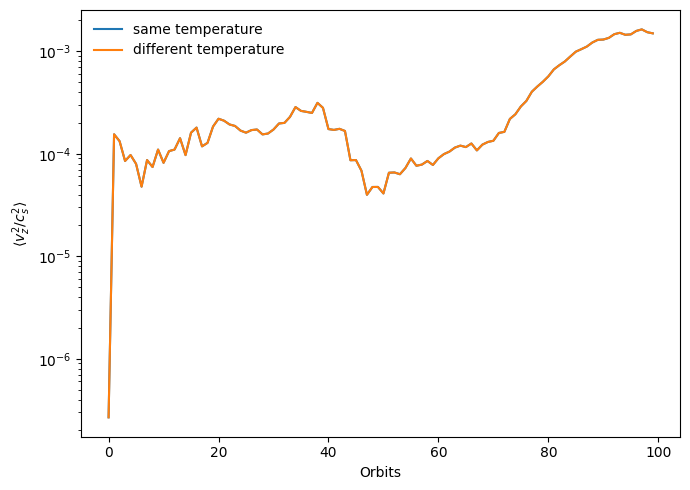

In [58]:
import numpy as np
import os
import matplotlib.pyplot as plt


# ==========================================================
# USER SETTINGS
# ==========================================================
r_target = 30.0      # AU
dR       = 3       # radial half-width (AU)
N        = 100       # number of outputs
fluidname = "gas"

k_B = 1.380649e-16       # erg/K
m_p = 1.6726219e-24      # g
mu = 2.4               # mean molecular weight for molecular gas
m_gas = mu * m_p
dust_internal_density = 2.0  # g/cm^3 (example)

period = 0.314159265359* 20    #time in code units for 1 whole period
amin = 1e-4 
NFLUIDS = 6
G_cgs = 6.674e-8
M_cgs =1.9891e33
R0_cgs = 30.0*1.49597871e13
Rmu_cgs = 36149835
mass_units = M_cgs
density_units = M_cgs / R0_cgs**3

temp_units = G_cgs*M_cgs/R0_cgs/Rmu_cgs   # from code units to cgs
k_B_units = G_cgs*M_cgs**2/R0_cgs / temp_units
# k_B_units = M_cgs* Rmu_cgs # is this correct
t_units = np.sqrt(G_cgs*M_cgs/R0_cgs**3)**(-1) 
rate_units = np.sqrt(G_cgs*M_cgs/R0_cgs**3)


aspect = 0.06
gamma =1.4
q = 1
nz, ny = 128, 128
H0 = 0.06

GAMMA = 1.4
cv = 1.0 / (GAMMA - 1.0)
# cp = GAMMA * cv
cd = 0.088 * cv
v_unit = R0_CGS/t_units


# List as many paths as you want
paths = {
    "same temperature": "../../outputs/vsi_sametemp/",
    "different temperature": "../../outputs/vsi_diffT/",
}

# ==========================================================
# LOAD GRID
# ==========================================================
def load_grid(path):
    rmin = np.loadtxt(path + "domain_y.dat")[3:-3]
    tmin = np.loadtxt(path + "domain_z.dat")[3:-3]

    rmed = 0.5 * (rmin[1:] + rmin[:-1])
    tmed = 0.5 * (tmin[1:] + tmin[:-1])

    R, T = np.meshgrid(rmed, tmed)

    r = 30 * R * np.sin(T)
    Z = np.cos(T) / H0

    return r, Z


# ==========================================================
# LOAD ONE SNAPSHOT
# ==========================================================
def load_snapshot(n, path, fluidname):

    dens = np.fromfile(f"{path}{fluidname}dens{n}.dat").reshape(nz, ny)
    ener = np.fromfile(f"{path}{fluidname}energy{n}.dat").reshape(nz, ny)
    vz   = np.fromfile(f"{path}{fluidname}vz{n}.dat").reshape(nz, ny)

    if fluidname == "gas":
        temp = ener / (dens * cv)
    else:
        temp = ener / (dens * cd)

    return dens, temp, vz


# ==========================================================
# COMPUTE TIME SERIES FOR ONE PATH
# ==========================================================
def compute_vz2_timeseries(path, fluidname):

    r, Z = load_grid(path)
    vz2_time = []

    for n in range(N):

        filename = f"{path}{fluidname}vz{n}.dat"
        if not os.path.exists(filename):
            continue

        dens, temp, vz = load_snapshot(n, path, fluidname)
        cs0 = np.sqrt(k_B  * temp * temp_units / (np.pi * m_gas)) /v_unit
        vz = vz/cs0
        H = 2.0

        radial_mask   = np.abs(r - r_target) < dR
#         radial_mask1   = r <45  
#         radial_mask2    = r> 22
        vertical_mask = np.abs(Z) <= H
#         mask = radial_mask1 & radial_mask2 & vertical_mask
        mask = radial_mask & vertical_mask

        
        if np.sum(mask) == 0:
            vz2_time.append(np.nan)
            continue

        vz2_avg = np.sum(dens[mask] * vz[mask]**2) / np.sum(dens[mask])
        vz2_avg = np.mean( vz[mask]**2)   #/ np.sum(dens[mask])
        vz2_time.append(vz2_avg)

    return np.array(vz2_time)



results = {}

for label, path in paths.items():
    print(f"Processing {label}")
    results[label] = compute_vz2_timeseries(path, fluidname)


plt.figure(figsize=(7,5))

dt = 1.0  # replace with real timestep

for label, series in results.items():
    time = np.arange(len(series)) * dt
    plt.semilogy(time, series, label=label)

plt.xlabel("Orbits")
plt.ylabel(r"$\langle v_z^2/c_s^2 \rangle$")
# plt.title(r"$\langle v_z^2 \rangle$ within 1H at R=30 AU")
plt.legend(frameon=False)
plt.tight_layout()
# plt.xlim(0, 79)
plt.savefig("vz2_vs_time_all_runs.pdf")
plt.show()

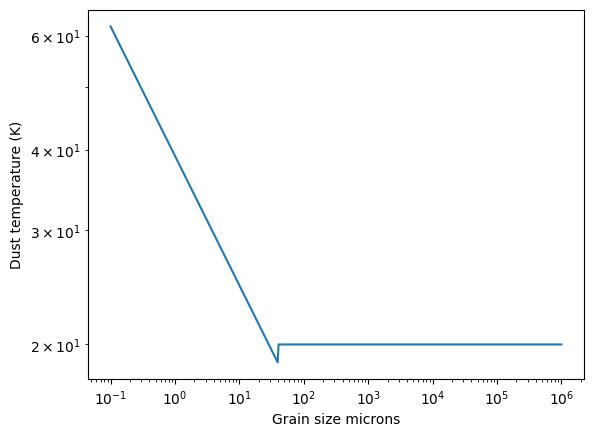

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- physical constants (CGS where needed, but ratios dominate here) ---
PLANCK = 6.626e-27      # erg s
C0 = 3.0e10             # cm/s
KBOLTZ = 1.38e-16       # erg/K
M_PI = np.pi

R0 = 1.0
R0_CGS = 1.0

# --- dust temperature function (translation of your C code) ---
def get_dust_temperature(teff, stokes_val):
    x = 2.0 * np.pi * stokes_val

    lambda_irr = 0.00001#0.29/teff

    grain_size_cgs = stokes_val 

    # Regime 1: Small grains
    if x < lambda_irr:
        return (PLANCK * C0 / (4.0 * (lambda_irr) * KBOLTZ))**0.2 * teff**0.8

    # Regime 2: Intermediate grains
    tdust = (PLANCK * C0 / (4.0 * (lambda_irr) * KBOLTZ))**0.2 * teff**0.8
    if grain_size_cgs < PLANCK * C0 / (4.0 * KBOLTZ * tdust):
        return (PLANCK * C0 / (8.0 * np.pi * grain_size_cgs * KBOLTZ))**0.2 * teff**0.8

    # Regime 3: Large grains
    return teff


# --- sweep grain size ---
teff = 20  # example stellar temperature in K

stokes_vals = np.logspace(-5, 2, 500)

temps = np.array([get_dust_temperature(teff, s) for s in stokes_vals])

# --- plot ---
plt.figure()
plt.loglog(stokes_vals*1e4, temps)
plt.xlabel("Grain size microns")
plt.ylabel("Dust temperature (K)")
plt.show()

In [120]:
0.29/0.01

28.999999999999996